# Evaluacion de la Confiabilidad del modelo 

## Cargar Datos

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.model_selection import train_test_split



url= "../../Dataset/data/access_log_master_manual_lab_if_score.csv"

df = pd.read_csv(url)
# Subconjunto con etiquetas humanas válidas
df_eval = df[df["anomaly"] != -1].copy()




In [64]:
total=len(df)
parte=len(df_eval)
porcentaje= (parte/total)*100

print("total de muestras",total)
print("Parte Muestral Evaluada",parte)
print("Porcentaje que representa",porcentaje)
df_eval["anomaly"].value_counts()

total de muestras 1054606
Parte Muestral Evaluada 579242
Porcentaje que representa 54.924967238949904


anomaly
0    492261
1     86981
Name: count, dtype: int64

## Preprocesamiento

In [65]:
df_eval["anomaly_gt"] = df_eval["anomaly"].map({
    0: 1,
    1: -1
})

## Matriz de Confusion

In [66]:
y_true = df_eval["anomaly_gt"]
y_pred = df_eval["if_prediction"]

# Definimos explícitamente el orden (-1 anomalía, +1 normal)
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[-1, 1]
)

TN, FP, FN, TP = cm.ravel()



## Grafica de la Matriz de confusion

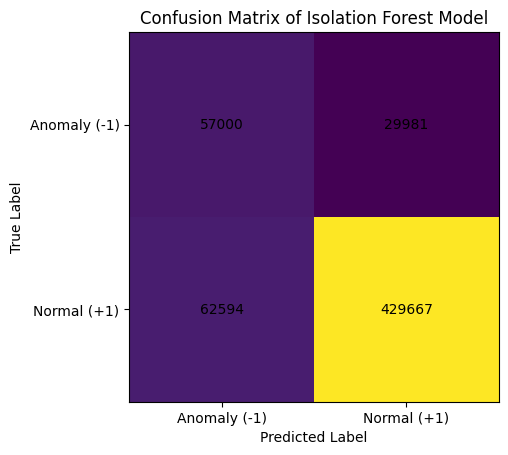

In [67]:


fig, ax = plt.subplots()

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Anomaly (-1)", "Normal (+1)"])
ax.set_yticklabels(["Anomaly (-1)", "Normal (+1)"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix of Isolation Forest Model")

plt.savefig("confusion_matrix.png")


## Procentajes de Clasificacion

In [68]:
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
cm_percent


array([[65.53155287, 34.46844713],
       [12.71561225, 87.28438775]])

## Metricas Evaluadas

In [69]:
y_true = df_eval["anomaly"].map({0: 0, 1: 1})
y_pred = df_eval["if_prediction"].map({1: 0, -1: 1})

N_ITER = 20          # número de repeticiones
TEST_SIZE = 0.3     # 30% para evaluación

metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

for i in range(N_ITER):
    idx_train, idx_test = train_test_split(
        df_eval.index,
        test_size=TEST_SIZE,
        random_state=i
    )

    y_true_i = y_true.loc[idx_test]
    y_pred_i = y_pred.loc[idx_test]

    metrics["accuracy"].append(
        accuracy_score(y_true_i, y_pred_i)
    )
    metrics["precision"].append(
        precision_score(y_true_i, y_pred_i, zero_division=0)
    )
    metrics["recall"].append(
        recall_score(y_true_i, y_pred_i)
    )
    metrics["f1"].append(
        f1_score(y_true_i, y_pred_i)
    )


In [ ]:
results = {}

for metric, values in metrics.items():
    results[metric] = {
        "mean": np.mean(values),
        "std":  np.std(values),
        "min":  np.min(values),
        "max":  np.max(values)
    }

results_df = pd.DataFrame(results).T
results_df


,mean,std,min,max
accuracy,0.840016,0.000852,0.837932,0.841172
precision,0.476134,0.002156,0.470533,0.480152
recall,0.655208,0.002857,0.650660,0.660343
f1,0.551496,0.002111,0.546687,0.555377


# Intervalo de confianza

In [71]:
from scipy import stats

confidence_intervals = {}

for metric, values in metrics.items():
    mean = np.mean(values)
    std = np.std(values, ddof=1)
    ci = stats.t.interval(
        0.95,
        len(values)-1,
        loc=mean,
        scale=std / np.sqrt(len(values))
    )
    confidence_intervals[metric] = ci

confidence_intervals


{'accuracy': (np.float64(0.8396070389384047), np.float64(0.8404249568261846)),
 'precision': (np.float64(0.4750985206717735),
  np.float64(0.47716919253325807)),
 'recall': (np.float64(0.6538363127504672), np.float64(0.6565804459240658)),
 'f1': (np.float64(0.5504823774445465), np.float64(0.5525092524769869))}

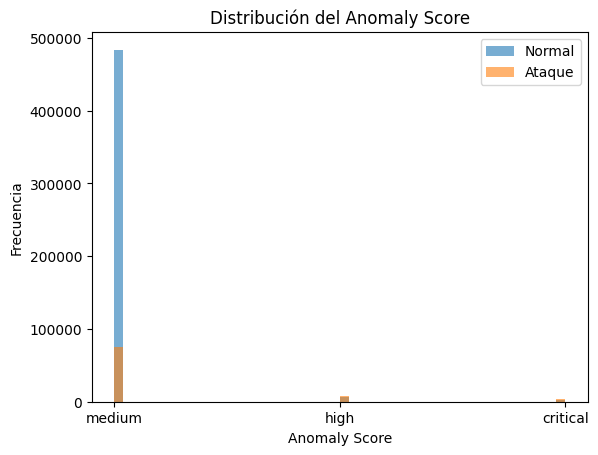

In [72]:

plt.figure()
plt.hist(
    df_eval[df_eval["anomaly"] == 0]["severity"],
    bins=50,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    df_eval[df_eval["anomaly"] == 1]["severity"],
    bins=50,
    alpha=0.6,
    label="Ataque"
)

plt.legend()
plt.title("Distribución del Anomaly Score")
plt.xlabel("Anomaly Score")
plt.ylabel("Frecuencia")
plt.savefig("anomaly_score_distribution.png")


In [73]:
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0 else 0
)


In [74]:
results_table = pd.DataFrame({
    "Metric": [ "Precision", "Recall", "F1-score"],
    "Value": [
        precision,
        recall,
        f1_score
    ]
})

results_table


,Metric,Value
0,Precision,0.934774
1,Recall,0.872844
2,F1-score,0.902748


## Evaluacion por Tipo de ataques

In [75]:
attack_eval = (
    df_eval[df_eval["anomaly_gt"] == -1]
    .groupby("severity")
    .agg(
        total_samples=("severity", "count"),
        detected_attacks=("if_prediction", lambda x: (x == -1).sum())
    )
)

attack_eval["detection_rate"] = (
    attack_eval["detected_attacks"] / attack_eval["total_samples"]
)

attack_eval.head()


,total_samples,detected_attacks,detection_rate
severity,,,
critical,4275,4275,1.000000
high,7794,7794,1.000000
medium,74912,44931,0.599784


## Analisis de anomaly score

In [76]:

df_eval["user_agent_occurrences"] = (
    df_eval.groupby("user_agent")["user_agent"].transform("count")
)

df_eval["IOC_occurrences"] = (
    df_eval["url__count_sql_words"]
  + df_eval["url__count_xss_words"]
  + df_eval["url__count_command_words"]
  + df_eval["url__count_auth_words"]
  + df_eval["url__count_error_words"]
  + df_eval["url__count_malware_words"]
  + df_eval["url__count_obfuscation_code_words"]
  + df_eval["url__count_dir_words"]
)

df_eval.groupby("anomaly_gt")["severity"].describe()

,count,unique,top,freq
anomaly_gt,,,,
-1,86981,3,medium,74912
1,492261,3,medium,483662


# Visualizacion de los datos 

## Features analizadas

In [77]:
# Vista general del esquema

FEATURE_COLUMNS = [
    "status",
    "size",
    "status_category",

    "url__count_sql_words",
    "url__count_xss_words",
    "url__count_command_words",
    "url__count_auth_words",
    "url__count_error_words",
    "url__count_malware_words",
    "url__count_danger_characters",
    "url__count_obfuscation_code_words",
    "url__count_dir_words",
    "url__count_dot",
    "url__count_http",
    "url__count_percentage_symbol",
    "url__count_question_symbol",
    "url__count_hyphen",
    "url__count_equal",
    "url__url_length",
    "url__digit_count",
    "url__letter_count",
    "url__count_special_characters",
    "url__is_encoded",
    "url__unusual_character_ratio",
]

schema = pd.DataFrame({
    "Column": df_eval.columns,
    "Data Type": df_eval.dtypes.astype(str)
})

schema


,Column,Data Type
ip_client,ip_client,object
timestamp,timestamp,object
status,status,int64
size,size,int64
user_agent,user_agent,object
method,method,object
url,url,object
protocol,protocol,object
anomaly,anomaly,int64
status_category,status_category,int64


In [78]:
schema_testing = schema.loc[
    schema["Column"].isin(FEATURE_COLUMNS)
]

schema_testing


,Column,Data Type
status,status,int64
size,size,int64
status_category,status_category,int64
url__count_sql_words,url__count_sql_words,int64
url__count_xss_words,url__count_xss_words,int64
url__count_command_words,url__count_command_words,int64
url__count_auth_words,url__count_auth_words,int64
url__count_error_words,url__count_error_words,int64
url__count_malware_words,url__count_malware_words,int64
url__count_danger_characters,url__count_danger_characters,int64


In [79]:
df_eval["if_prediction"].value_counts().head()

if_prediction
 1    459648
-1    119594
Name: count, dtype: int64

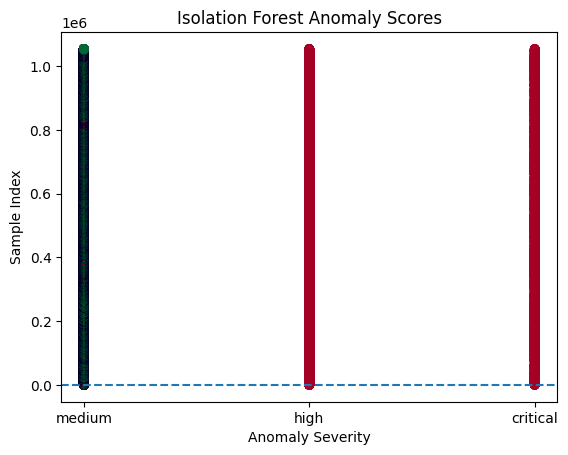

In [80]:
plt.figure()
plt.scatter(
    df_eval["severity"],
    df_eval.index,
    c=df_eval["if_prediction"],
    cmap="RdYlGn"
)
plt.axhline(0, linestyle="--")
plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Severity")
plt.ylabel("Sample Index")
plt.savefig("anomaly_severity_scatter.png")


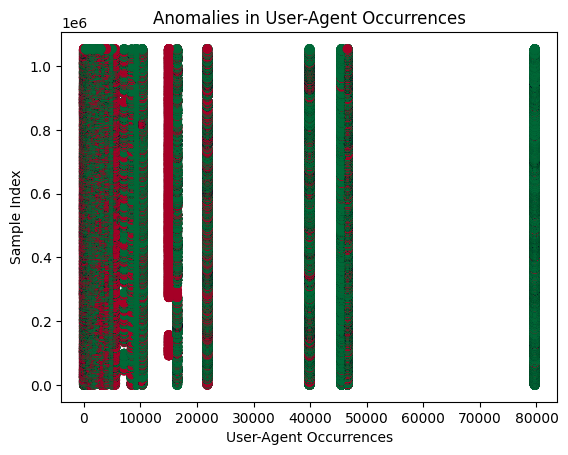

In [81]:
plt.figure()
plt.scatter(
    df_eval["user_agent_occurrences"],
    df_eval.index,
    c=df_eval["if_prediction"],
    cmap="RdYlGn"
)
plt.xlabel("User-Agent Occurrences")
plt.ylabel("Sample Index")
plt.title("Anomalies in User-Agent Occurrences")
plt.savefig("user_agent_occurrences_scatter.png")

## Comparacion de Features 

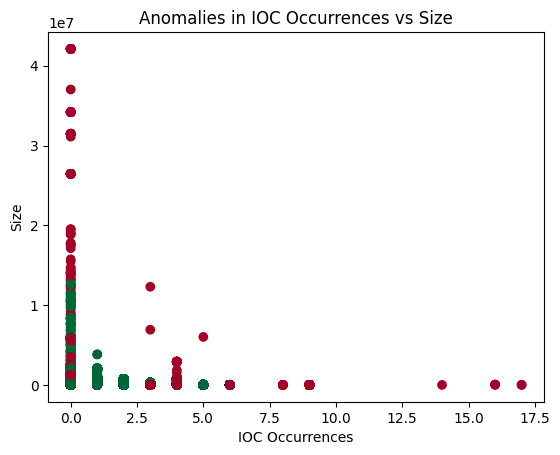

In [82]:
plt.figure()
plt.scatter(
    df_eval["IOC_occurrences"],
    df_eval["size"],
    c=df_eval["if_prediction"],
    cmap="RdYlGn"
)
plt.xlabel("IOC Occurrences")
plt.ylabel("Size")
plt.title("Anomalies in IOC Occurrences vs Size")
plt.savefig("ioc_occurrences_size_scatter.png")

## Longitud de URL vs Caracteres Especiales
### Objetivo: Detectar payloads largos y sintácticamente complejos (SQLi / XSS).

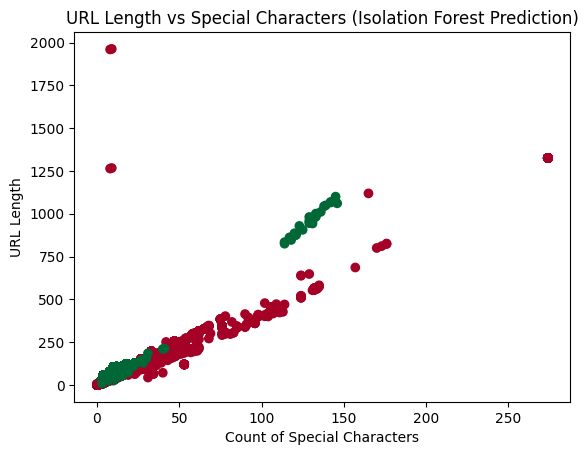

In [83]:
plt.figure()
plt.scatter(
    df_eval["url__count_special_characters"],
    df_eval["url__url_length"],
    c=df_eval["if_prediction"],
    cmap= "RdYlGn"
)

plt.xlabel("Count of Special Characters")
plt.ylabel("URL Length")
plt.title("URL Length vs Special Characters (Isolation Forest Prediction)")
plt.savefig("url_length_special_characters_scatter.png")

## Ratio de caracteres inusuales vs ofuscación
### Objetivo: Visualizar técnicas de evasión y encoding.

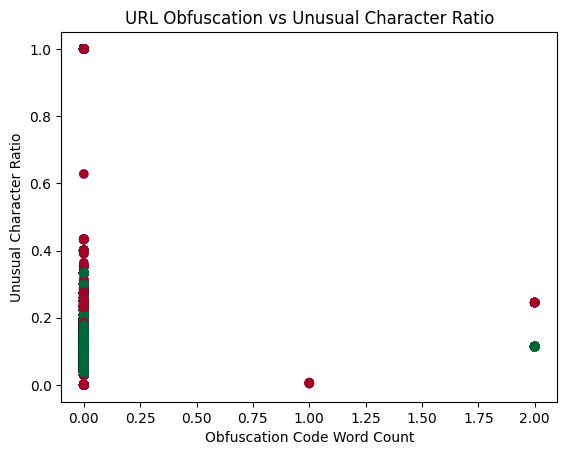

In [84]:
plt.figure()
plt.scatter(
    df_eval["url__count_obfuscation_code_words"],
    df_eval["url__unusual_character_ratio"],
    c=df_eval["if_prediction"],
    cmap="RdYlGn"
)

plt.xlabel("Obfuscation Code Word Count")
plt.ylabel("Unusual Character Ratio")
plt.title("URL Obfuscation vs Unusual Character Ratio")
plt.savefig("url_obfuscation_unusual_character_ratio_scatter.png")


In [85]:
df_eval['url__count_obfuscation_code_words'].value_counts()

url__count_obfuscation_code_words
0    579043
2       195
1         4
Name: count, dtype: int64

## IOC Occurrences vs Método HTTP
### Objetivo: Relacionar contenido malicioso con el tipo de operación HTTP.

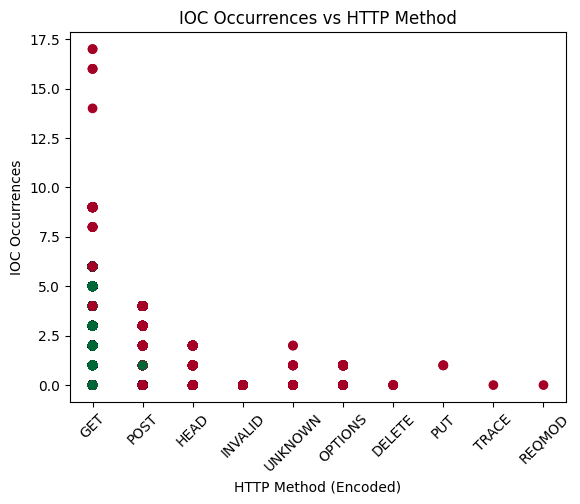

In [86]:
plt.figure()
plt.scatter(
    df_eval["method"],
    df_eval["IOC_occurrences"],
    c=df_eval["if_prediction"],
    cmap="RdYlGn"
)
plt.xticks(rotation=45)
plt.xlabel("HTTP Method (Encoded)")
plt.ylabel("IOC Occurrences")
plt.title("IOC Occurrences vs HTTP Method")
plt.savefig("ioc_occurrences_http_method_scatter.png")